In [1]:
import pandas as pd

df= pd.read_csv("./Housing.csv")

In [17]:
print("The shape of the dataset is:")
df.shape

The shape of the dataset is:


(545, 13)

In [15]:
print("First 5 Rows:")
df.head()

First 5 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
print("Column Headers:")
df.columns

Column Headers:


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style= "whitegrid")

In [27]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [23]:
duplicates= df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

if duplicates > 0:
    df= df.drop_duplicates()
    print("Duplicates removed.")


Duplicate Rows: 0


In [25]:
# 3. Check Data Types
# We verify that categorical columns are 'object' and numerical are 'int64'
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


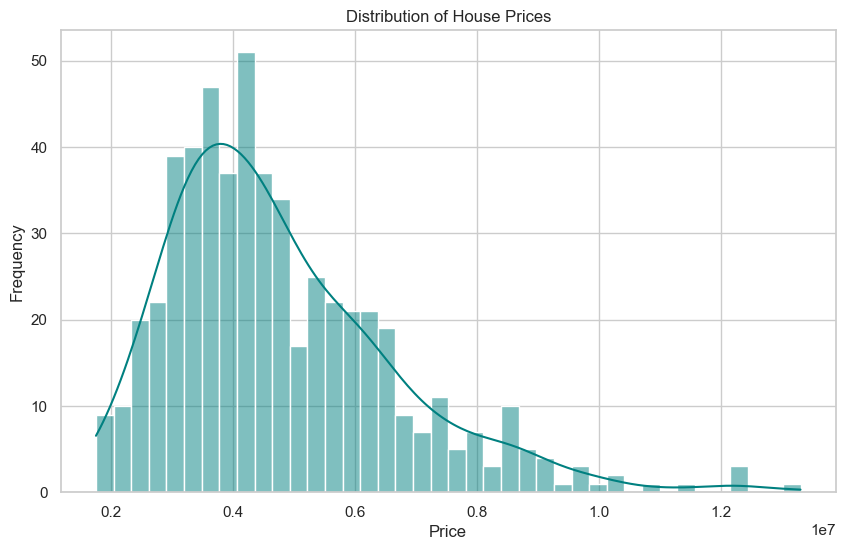

In [33]:
plt.figure(figsize= (10, 6))
sns.histplot(df["price"], kde= True, bins= 40, color= "teal")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

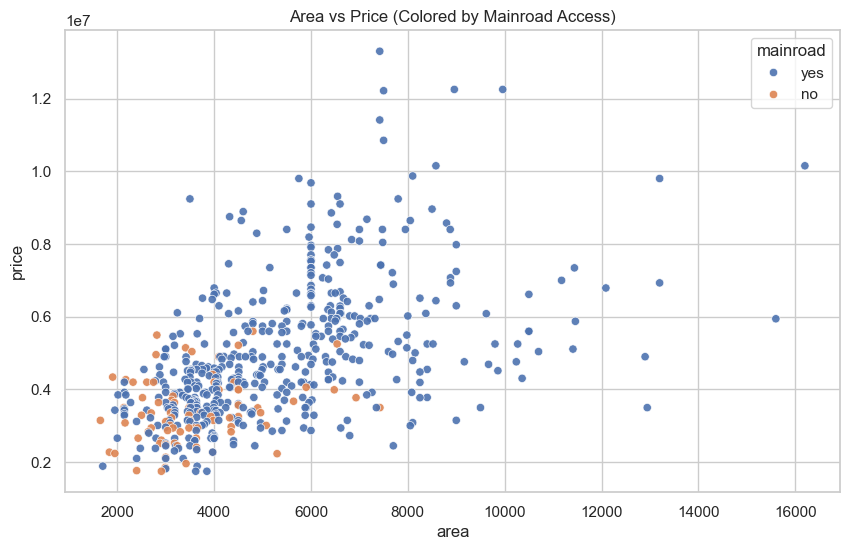

In [35]:
plt.figure(figsize= (10, 6))
sns.scatterplot(x= "area", y= "price", data= df, hue= "mainroad", palette= "deep", alpha= 0.9)
plt.title("Area vs Price (Colored by Mainroad Access)")
plt.show()

/var/folders/pd/h_jrc1ln51s3vk4y71hqk6rm0000gn/T/ipykernel_8888/4098824278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= col, y="price", data= df, palette= "Set2")
/var/folders/pd/h_jrc1ln51s3vk4y71hqk6rm0000gn/T/ipykernel_8888/4098824278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= col, y="price", data= df, palette= "Set2")
/var/folders/pd/h_jrc1ln51s3vk4y71hqk6rm0000gn/T/ipykernel_8888/4098824278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= col, y="price", data= df, palette= "Set2")
/var/folders/pd/h_jrc1ln51s3

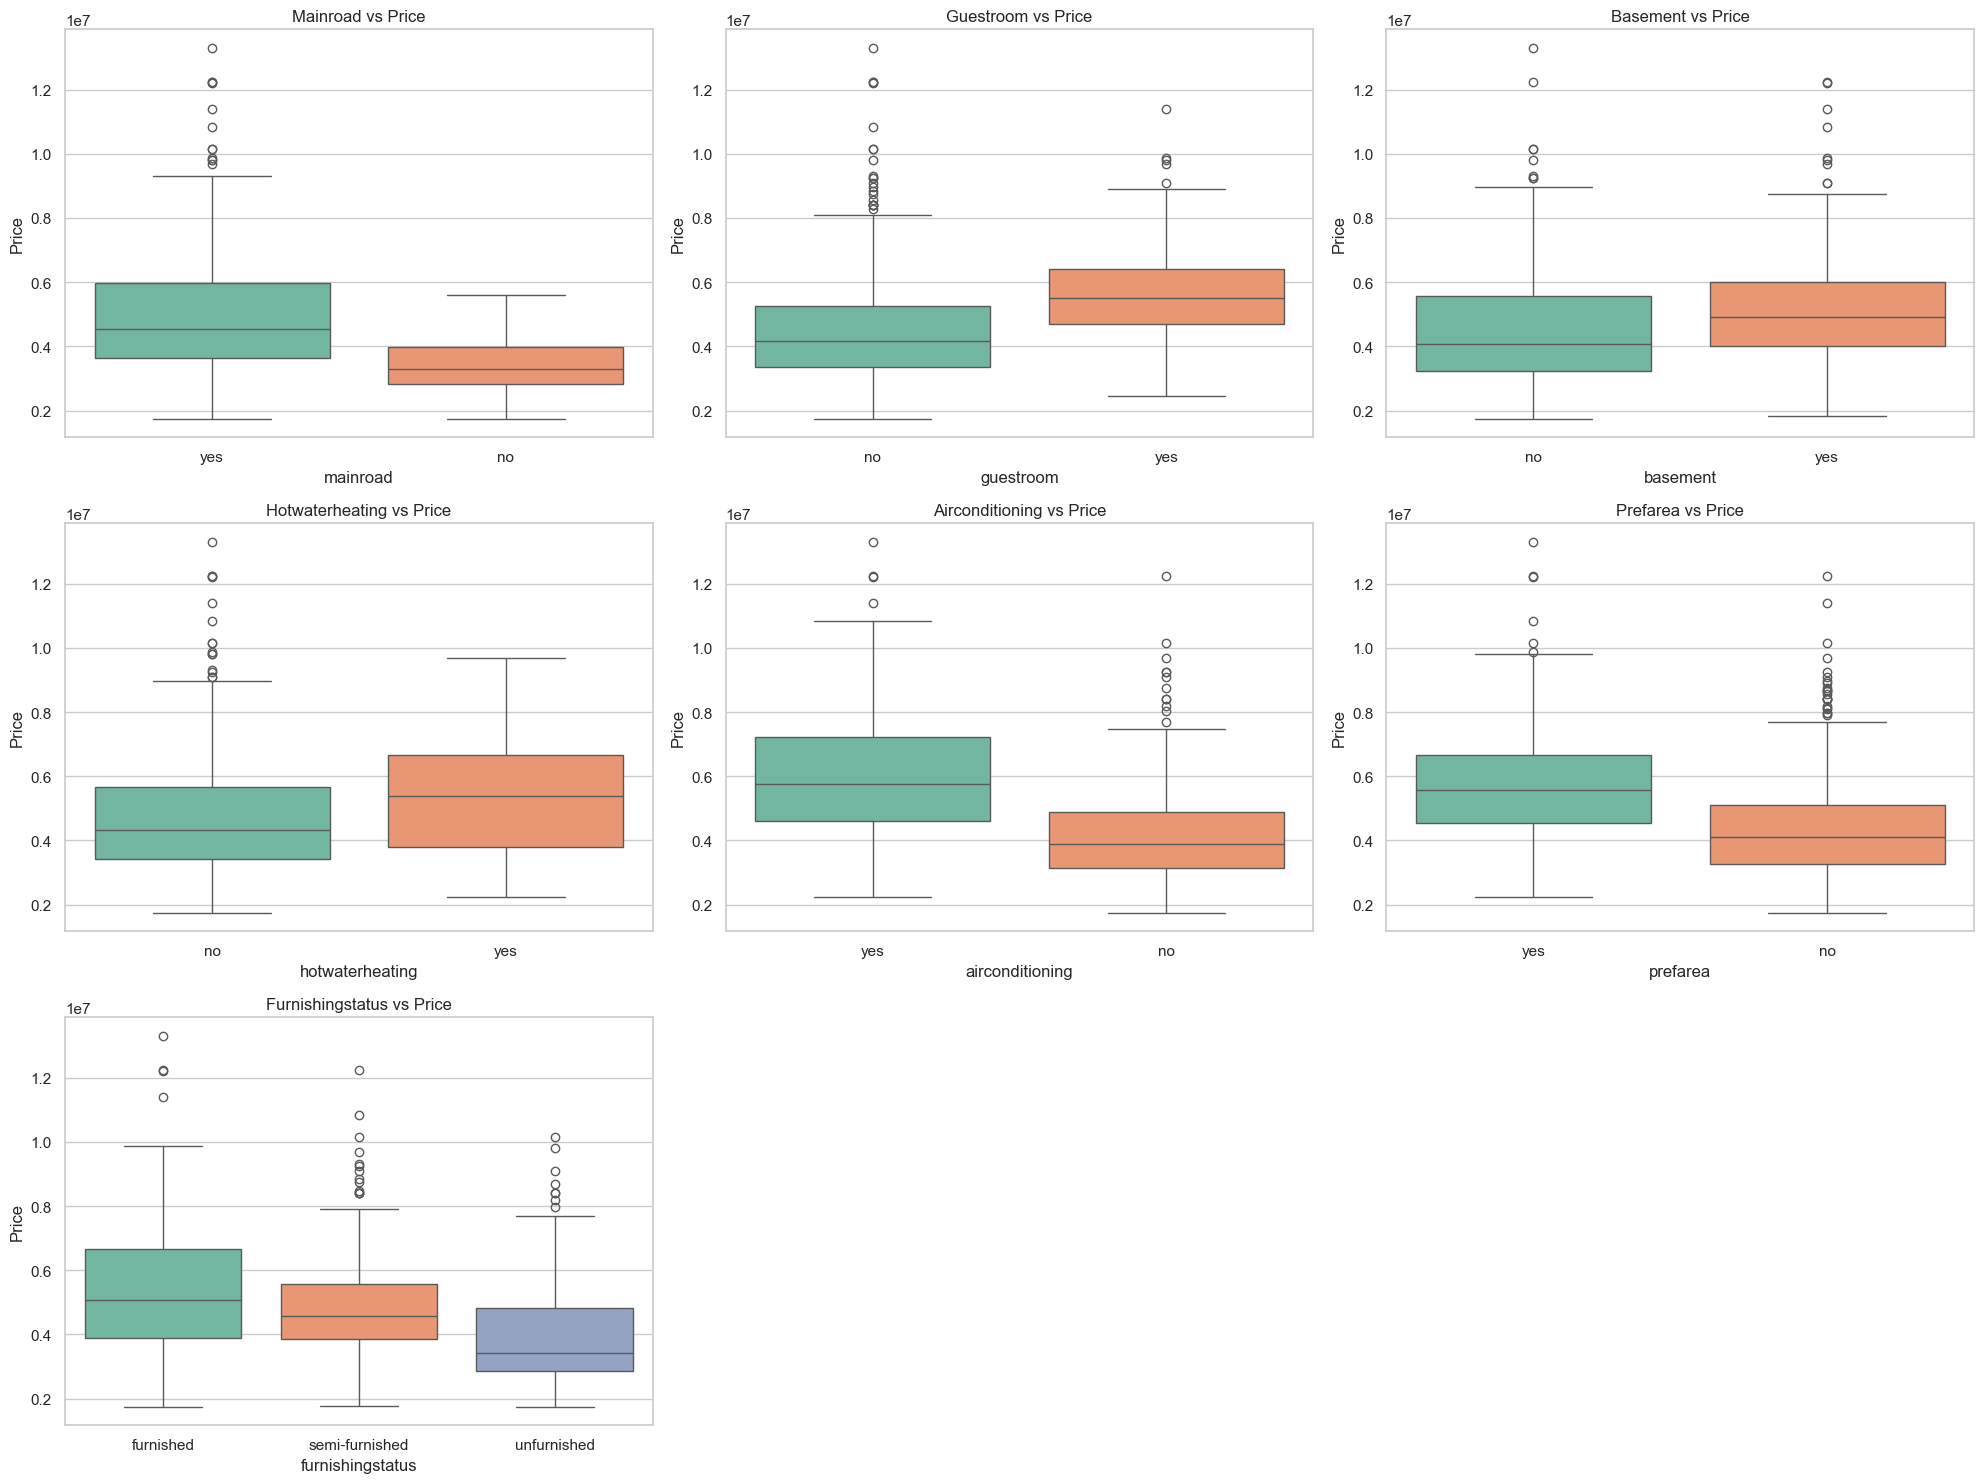

In [38]:
categorical_cols= ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]

plt.figure(figsize= (20, 15))

for idx, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, idx)
    sns.boxplot(x= col, y="price", data= df, palette= "Set2")
    plt.title(f"{col.title()} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")

plt.tight_layout()
plt.show()

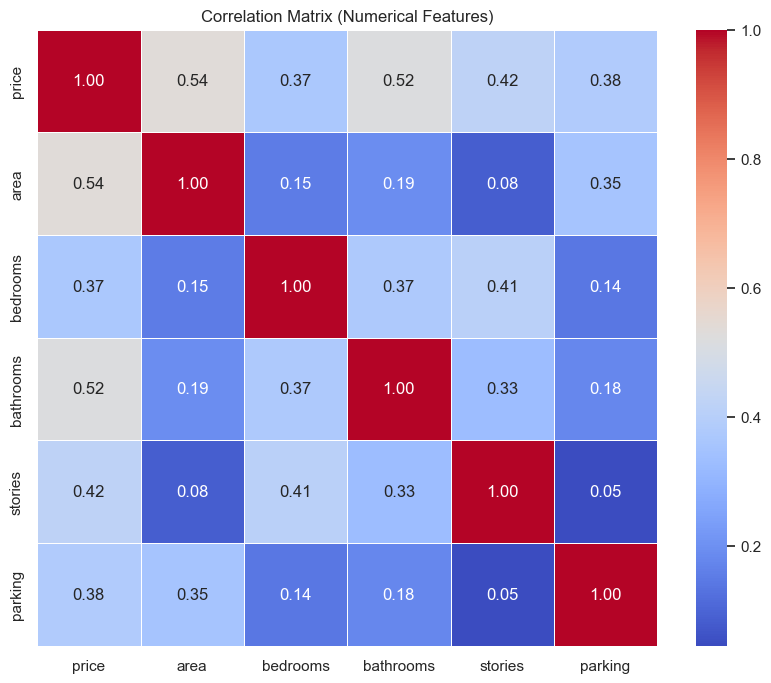

In [39]:
numerical_df= df.select_dtypes(include= ["int64", "float64"])

plt.figure(figsize= (10, 8))
sns.heatmap(numerical_df.corr(), annot= True, cmap= "coolwarm", fmt= ".2f", linewidths= 0.5)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()